# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.plot import Plot

# frank1d
from frank.utilities import UVDataBinner

## Functions

In [5]:
def calculate_resolution( clean_beam, intrinsic_resolution):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - intrinsic_resolution**2)
    final_bmin_as = np.sqrt(bmin_as**2 - intrinsic_resolution**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [6]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [7]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

# Data

In [8]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [9]:
data = AS209

# UVtable
dir = "../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

In [10]:
# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [11]:
imsize = 3000

In [37]:
cell = 2*rout/imsize  # arcsec
cell

0.0015999999999999999

In [12]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [13]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [14]:
best = {'m': -1.3620942401288272, 'c': 4681.245509195992, 'l': 72454.18892316935}

In [15]:
frank2d = Frank2D(imsize, rout, geom_f2d)

===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
     + Kernel parameters:  {'m': -1.3620942401288272, 'c': 4681.245509195992, 'l': 72454.18892316935}
===>  Creating sparse linear system...
    + time kernel = 0.05  min |  3.21 seconds
Using preconditioner method:  jacobi
    + time building system = 0.05  min |  3.29 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-08
         * rtol: 1e-08
         * final tolerance: 2.881752289367308
     + final tolerance :  2.881752289367308
                       .... iteration:  0
                        -> actual tol:  288175228.9367308  vs  2.881752289367308
                       .... iteration:  1
                        -> actual tol:  26326262.02961506  vs  2.881752289367308
                       .... iteration:  2
                        -> actual tol:  23214465.584248908  vs  2.881752289367308
                       .... iteration:  3
                        -> actual tol:  23233908.31311694 

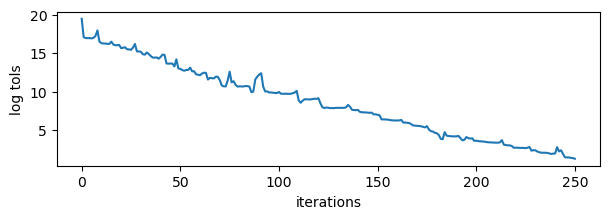

    + time = 0.17  min |  10.50 seconds
     + CGM converged?   True
True
         ✔✔✔✔✔✔✔ CGM Sucess..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 4.35  min |  261.06 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = 3000 took 295.0200307369232 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [16]:
start_time = time.time()
frank2d.fit(data = uvtable, kernel_params = best, rtol = 1e-8 )

end_time = time.time()
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {imsize} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

### Open fits file
Of image regridded in CASA with imregrid, the same image from where we got the CLEAN model.

In [57]:
from astropy.io import fits
dir_  = "../../data/"

disk = "AS209" + '_model.fits' # this is the model regridded!

fits_name = dir_ + disk

In [58]:

hdul = fits.open(fits_name)

In [18]:
import matplotlib.colors as colors

### CLEAN model imregridded

In [19]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

In [20]:
hdr = hdul[0].header
data = hdul[0].data 

In [21]:
# beam
bmaj = hdr.get('BMAJ') # degrees
bmaj_arsec = bmaj * 3600 # arcseconds
bmin = hdr.get('BMIN')
bmin_arsec = bmin * 3600 # arcseconds
bpa = hdr.get('BPA')

In [22]:
w = WCS(hdr)

In [23]:
data_squeezed = np.squeeze(data)   # (3000,3000) si los ejes 1 desaparecen
print("shape original:", data.shape, "-> squeezed:", data_squeezed.shape)

shape original: (1, 1, 3000, 3000) -> squeezed: (3000, 3000)


In [24]:
data = data_squeezed

In [25]:
if data.ndim == 3:
    # asumo (nz, ny, nx)
    nz, ny, nx = data.shape
    if channel_index is None:
        # elige el canal central por defecto
        ci = nz // 2
    else:
        ci = int(channel_index)
    img = data[ci, :, :].copy()
    # build a WCS for the 2D plane (drop the spectral axis)
    w2 = w.celestial  # WCS restringido a ejes celestes (RA/Dec)
else:
    ny, nx = data.shape
    img = data.copy()
    w2 = w.celestial

In [26]:
# pixel coordinates
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)

# wcs expects pixel coords in 1-based -> use wcs_pix2world with origin=0
ra_deg, dec_deg = w2.wcs_pix2world(xx, yy, 0)  # devuelve en grados

# reference coordinate (CRVAL)
crval_ra = w2.wcs.crval[0]
crval_dec = w2.wcs.crval[1]
refcoord = SkyCoord(crval_ra*u.deg, crval_dec*u.deg)

# compute offsets in arcsec from reference coordinate
coords = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
lon_off, lat_off = coords.spherical_offsets_to(refcoord)
# convertir a arcsec, y poner el eje x como RA offset (positivo hacia el Este)
ra_off_arcsec = -lon_off.to(u.arcsec).value
dec_off_arcsec = lat_off.to(u.arcsec).value

# extent of the image in arcsec (for imshow)
xmin = ra_off_arcsec.min()
xmax = ra_off_arcsec.max()
ymin = dec_off_arcsec.min()
ymax = dec_off_arcsec.max()

# we need to flip the y axis to match the imshow convention
img = np.flipud(img)



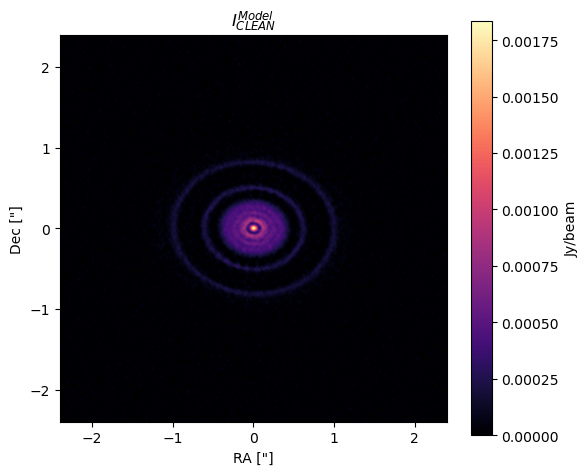

In [29]:
plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=1, vmin=0, vmax = img.max())
ax = plt.gca()
im = ax.imshow(
    img,
    extent=[xmin, xmax, ymin, ymax],
    aspect='equal',
    cmap='magma',
    norm=norm,
)
ax.set_xlabel('RA ["]')
ax.set_ylabel('Dec ["]')
ax.set_title(r'$I^{Model}_{CLEAN}$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(hdr.get('BUNIT', 'Intensity'))
#plt.xlim(0.3, -0.3)
#plt.ylim(-0.3, 0.3)
ax.grid(False)
plt.tight_layout()
plt.show()

In [30]:
# arcsecs per pixel
ra_off_arcsec[0][1] -ra_off_arcsec[0][0]

-0.0016000046066801943

### Convolve f2d

In [32]:
I_f2d = frank2d.intensity_model

In [33]:
I_f2d.shape 

(3000, 3000)

**Jy/sr $\implies$ Jy/beam**

In [34]:
FHWM_maj = bmaj_arsec / rad_to_arcsec
FHWM_min = bmin_arsec / rad_to_arcsec
omega = ( np.pi / 4 * np.log(2) ) * FHWM_maj * FHWM_min
I_f2d_Jybeam = I_f2d * omega

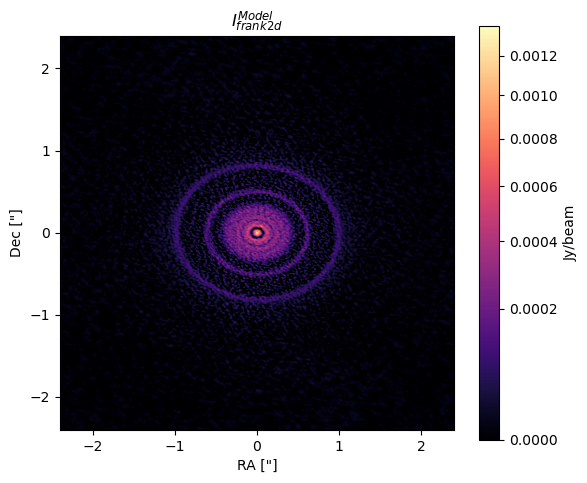

In [38]:
xmin = - (imsize/2) * cell
xmax = (imsize/2) * cell
ymin = - (imsize/2) * cell
ymax = (imsize/2) * cell


plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=0.6, vmin=0, vmax= I_f2d_Jybeam.max())
ax = plt.gca()
im = ax.imshow(
    I_f2d_Jybeam,
    extent=[xmin, xmax, ymin, ymax],
    aspect='equal',
    cmap='magma',
    norm=norm,
)
ax.set_xlabel('RA ["]')
ax.set_ylabel('Dec ["]')
cbar = plt.colorbar(im, ax=ax)
plt.title(r'$I^{Model}_{frank2d}$')
cbar.set_label('Jy/beam')
ax.grid(False)
plt.tight_layout()
plt.show()

**Convolution**

In [39]:
from radio_beam import Beam
from astropy.convolution import convolve_fft, Gaussian2DKernel

In [40]:
FWHM_frank2d = 23.5e-3

In [41]:
bmin_arsec

0.036224924027904

In [42]:
hdr['BMAJ']*u.deg

<Quantity 1.06156369e-05 deg>

In [43]:
# defining beams
beam_orig =  Beam(major=FWHM_frank2d*u.arcsec, minor=FWHM_frank2d*u.arcsec, pa=0*u.deg)
beam_target = Beam(major=bmaj_arsec*u.arcsec, minor=bmin_arsec*u.arcsec, pa=hdr['BPA']*u.deg)

In [44]:
# calculating convolution beam
conv_beam = beam_target.deconvolve(beam_orig)

In [45]:
# creating kernel in pixels
pixscale = abs(hdr['CDELT2'])*u.deg
sigma_conv_pix = (conv_beam.major / (2.355 * pixscale)).decompose().value
kernel = Gaussian2DKernel(sigma_conv_pix)

In [46]:
# convolve
I_f2d_Jybeam_conv = convolve_fft(I_f2d_Jybeam, kernel, boundary='wrap')

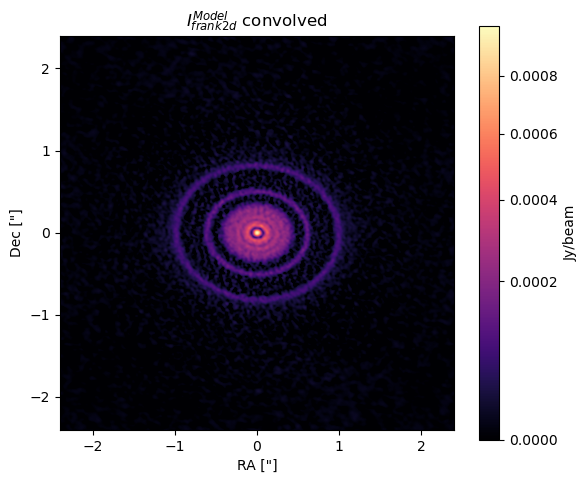

In [47]:
xmin = - (imsize/2) * cell
xmax = (imsize/2) * cell
ymin = - (imsize/2) * cell
ymax = (imsize/2) * cell

plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=0.6, vmin=0, vmax= I_f2d_Jybeam_conv.max())
ax = plt.gca()
im = ax.imshow(
    I_f2d_Jybeam_conv,
    extent=[xmin, xmax, ymin, ymax],
    aspect='equal',
    cmap='magma',
    norm=norm,
)
ax.set_xlabel('RA ["]')
ax.set_ylabel('Dec ["]')
ax.set_title('CLEAN')
cbar = plt.colorbar(im, ax=ax)
plt.title(r'$I^{Model}_{frank2d}$ convolved')
cbar.set_label('Jy/beam')
ax.grid(False)
plt.tight_layout()
plt.show()

#### Difference

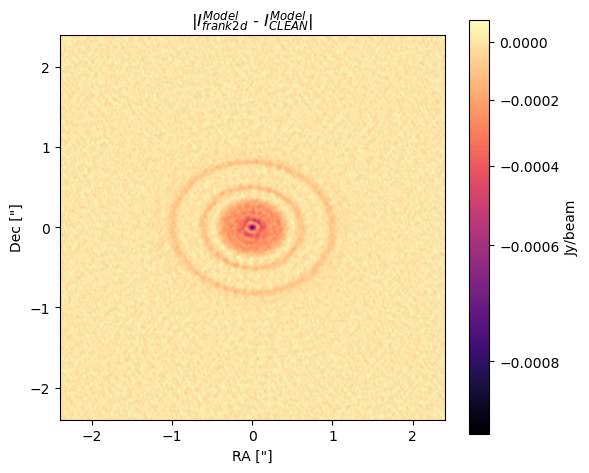

In [48]:
xmin = - (imsize/2) * cell
xmax = (imsize/2) * cell
ymin = - (imsize/2) * cell
ymax = (imsize/2) * cell

diff = I_f2d_Jybeam_conv - img

plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=0.6)
ax = plt.gca()
im = ax.imshow(
    diff,
    extent=[xmin, xmax, ymin, ymax],
    aspect='equal',
    cmap='magma',
    norm=norm,
)
ax.set_xlabel('RA ["]')
ax.set_ylabel('Dec ["]')
ax.set_title('CLEAN')
cbar = plt.colorbar(im, ax=ax)
plt.title(r'|$I_{frank2d}^{Model}$ - $I_{CLEAN}^{Model}$|')
cbar.set_label('Jy/beam')
ax.grid(False)
plt.tight_layout()
plt.show()

## 1D Profile

In [49]:
f2d = frank2d
geom = geom_f2d
inc, pa, dra, ddec = geom.inc, geom.pa, geom.dra, geom.ddec

FWHM_frank2d = 0

In [59]:
from gofish import imagecube
cube_1mm = imagecube(fits_name)
x_clean, y_clean, dy_clean = cube_1mm.radial_profile(inc= inc, PA=pa, x0=dra, y0=ddec)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


In [60]:
fits_image = fits.open(fits_name)
header = fits_image[0].header
bmaj_deg = float(header["BMAJ"])
bmin_deg = float(header["BMIN"])
bmaj_as = bmaj_deg * 3600.0
bmin_as = bmin_deg * 3600.0
bpa_deg = header['BPA']

clean_beam = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa_deg}
clean_area = clean_beam['bmaj']*clean_beam['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2
area = clean_area
print(f"Clean beam: {bmaj_as} x {bmin_as} arcsec")

beam_for_f2d = calculate_resolution(clean_beam, FWHM_frank2d)

Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
-> Final beam to convolve with: 0.038216292858108 x 0.036224924027904 arcsec


In [61]:
# f2d model
u_model = f2d.u_grid
v_model = f2d.v_grid
vis_model = f2d.visibility_model

u_model_1d = f2d.u
v_model_1d = f2d.v

x_model = f2d.x_grid * rad_to_arcsec
y_model = f2d.y_grid * rad_to_arcsec

x_model_1d = f2d.x * rad_to_arcsec
y_model_1d = f2d.y * rad_to_arcsec

        
# phase shift
vis = geom.apply_phase_shift(-u_model, -v_model, vis_model) # the East of North convention.
I = f2d.transform(vis).real

# deproject
x_model, y_model = geom.deproject_xy(x_model, y_model)
x_model_1d_d, y_model_1d_d = geom.deproject_xy(x_model_1d, y_model_1d)

# collocation points for the plot.
r = np.unique(np.hypot(x_model_1d_d, y_model_1d_d))
bins = 800
r = np.linspace(r.min(), r.max(), bins)
edges_ = edges(r)


r_model_1d, I_model_1d = get_profile(x_model, y_model, I, bins = edges_)
I_model_1d = np.nan_to_num(I_model_1d, nan=0)

In [62]:
from frank.utilities import convolve_profile
I_model_1d_convolved = convolve_profile(r_model_1d, I_model_1d, inc, pa, beam_for_f2d)
I_model_1d_convolved *= area # Jy/beam

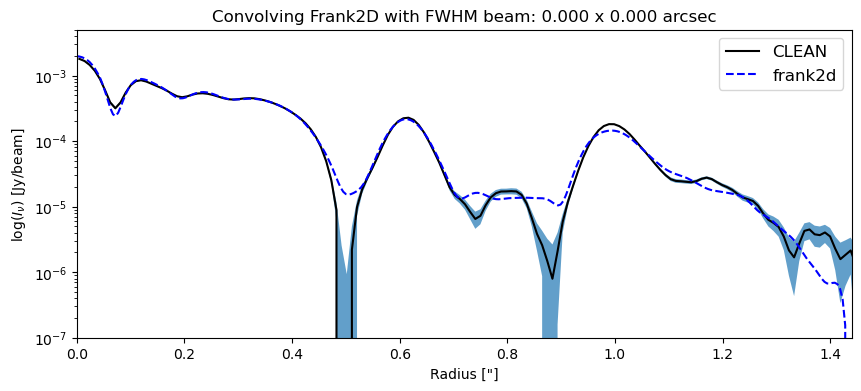

In [63]:
plt.figure(figsize=(10,4))
#  CLEAN --------------------------------------------------------------------
plt.plot(x_clean, y_clean, "black", label = "CLEAN")
plt.fill_between(x_clean, y_clean-dy_clean, y_clean+dy_clean, alpha=0.7)
# frank2D -------------------------------------------------------------------
plt.plot(r_model_1d, I_model_1d_convolved, color = 'blue',ls ='--', label = r'frank2d')

plt.ylabel(r'log($I_\nu$) [Jy/beam]', size=10)
plt.xlabel('Radius ["]', size=10)
plt.legend(fontsize=12)
plt.yscale('log')
plt.title(f'Convolving Frank2D with FWHM beam: {FWHM_frank2d:.3f} x {FWHM_frank2d:.3f} arcsec')
plt.xlim(0, rout*0.6)
plt.ylim(1e-7, 0.5e-2)
plt.show()

In [64]:
import pickle

path_f1d = "f1d_N1100_a1p05_w1em4_r2p4.pkl"

# Abrir y cargar el objeto
with open(path_f1d, 'rb') as f:   # 'rb' = read binary
    f1d = pickle.load(f)

In [65]:
FWHM_frank1d = 14.7e-3
beam_for_f1d = calculate_resolution(clean_beam, FWHM_frank1d)

-> Final beam to convolve with: 0.035275983895799085 x 0.03310823342957785 arcsec


In [71]:
r_f1d = f1d.r
I_f1d = f1d.mean
I_f1d_convolved = convolve_profile(r_f1d, I_f1d, inc, pa, beam_for_f1d)
I_f1d_convolved *= area # Jy/beam

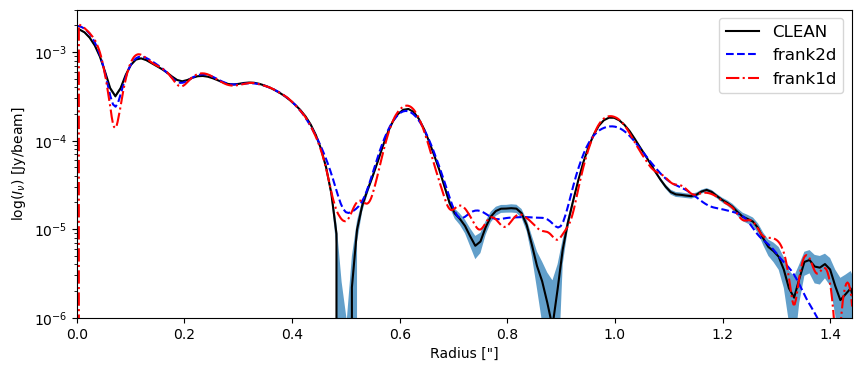

In [76]:
plt.figure(figsize=(10,4))
#  CLEAN --------------------------------------------------------------------
plt.plot(x_clean, y_clean, "black", label = "CLEAN")
plt.fill_between(x_clean, y_clean-dy_clean, y_clean+dy_clean, alpha=0.7)
# frank2D -------------------------------------------------------------------
plt.plot(r_model_1d, I_model_1d_convolved, color = 'blue',ls ='--', label = r'frank2d')
# frank1D -------------------------------------------------------------------
plt.plot(r_f1d, I_f1d_convolved, color = 'red',ls ='-.', label = r'frank1d')

plt.ylabel(r'log($I_\nu$) [Jy/beam]', size=10)
plt.xlabel('Radius ["]', size=10)
plt.legend(fontsize=12)
plt.yscale('log')
plt.title(f'')
plt.xlim(0, rout*0.6)
plt.ylim(1e-6, 0.3e-2)
plt.show()